In [3]:
# --- Setup Cell ---
# 1. 挂载 Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. 进入你的项目目录
%cd /content/drive/MyDrive/cs336_assignments/assignment1-basics

# 3. 安装依赖 (安装这个 -e . )
!pip install -e .

In [4]:
!pytest -q


tests/test_data.py::test_get_batch PASSED
tests/test_model.py::test_linear PASSED
tests/test_model.py::test_embedding PASSED
tests/test_model.py::test_swiglu PASSED
tests/test_model.py::test_scaled_dot_product_attention PASSED
tests/test_model.py::test_4d_scaled_dot_product_attention PASSED
tests/test_model.py::test_multihead_self_attention PASSED
tests/test_model.py::test_multihead_self_attention_with_rope PASSED
tests/test_model.py::test_transformer_lm PASSED
tests/test_model.py::test_transformer_lm_truncated_input PASSED
tests/test_model.py::test_transformer_block PASSED
tests/test_model.py::test_rmsnorm PASSED
tests/test_model.py::test_rope PASSED
tests/test_model.py::test_silu_matches_pytorch PASSED
tests/test_nn_utils.py::test_softmax_matches_pytorch PASSED
tests/test_nn_utils.py::test_cross_entropy PASSED
tests/test_nn_utils.py::test_gradient_clipping PASSED
tests/test_optimizer.py::test_adamw PASSED
tests/test_optimizer.py::test_get_lr_cosine_schedule PASSED
tests/test_seriali

In [4]:
%cd /content/drive/MyDrive/cs336_assignments/assignment1-basics

/content/drive/MyDrive/cs336_assignments/assignment1-basics


In [7]:
!python -u cs336_basics/train.py \
  --train-path data/tinystories_train.bin \
  --val-path data/tinystories_valid.bin \
  --vocab-size 10000 \
  --context-length 256 \
  --d-model 512 \
  --num-layers 4 \
  --num-heads 16 \
  --d-ff 1344 \
  --rope-theta 10000 \
  --batch-size 32 \
  --learning-rate 1.5e-3 \
  --beta1 0.9 \
  --beta2 0.95 \
  --eps 1e-8 \
  --weight-decay 0.1 \
  --num-iterations 40000 \
 --checkpoint-path data/no_rmsnorm_lr1p5e-3_checkpoint.pt \
  --checkpoint-interval 5000 \
  --log-interval 100 \
  --val-interval 500 \
  --val-batches 20 \
  --data-dtype uint16 \
  --device cuda \
  --min-learning-rate 1.5e-4 \
  --warmup-iters 4000 \
  --cosine-cycle-iters 40000 \
  --max-l2-norm 1.0 \
  --seed 42 \
  --metrics-path data/no_rmsnorm_lr1p5e-3_metrics.csv

iteration 100: train loss = 8.6604
iteration 200: train loss = 4.8458
iteration 300: train loss = 3.9501
iteration 400: train loss = 3.6289
iteration 500: train loss = 3.3298
iteration 500: val loss = 3.2965
iteration 600: train loss = 3.1294
iteration 700: train loss = 2.9254
iteration 800: train loss = 2.8703
iteration 900: train loss = 2.6773
iteration 1000: train loss = 2.7478
iteration 1000: val loss = 2.6534
iteration 1100: train loss = 2.5539
iteration 1200: train loss = 2.5777
iteration 1300: train loss = 2.4994
iteration 1400: train loss = 2.4472
iteration 1500: train loss = 2.2993
iteration 1500: val loss = 2.4580
iteration 1600: train loss = 2.2980
iteration 1700: train loss = 2.4614
iteration 1800: train loss = 2.2142
iteration 1900: train loss = 2.2902
iteration 2000: train loss = 2.2771
iteration 2000: val loss = 2.3296
iteration 2100: train loss = 2.3680
iteration 2200: train loss = 2.1793
iteration 2300: train loss = 2.2648
iteration 2400: train loss = 2.2028
iteration 

bad columns: ['step', 'train_loss', 'val_loss', 'elapsed_time']
good columns: ['step', 'train_loss', 'val_loss', 'elapsed_time']


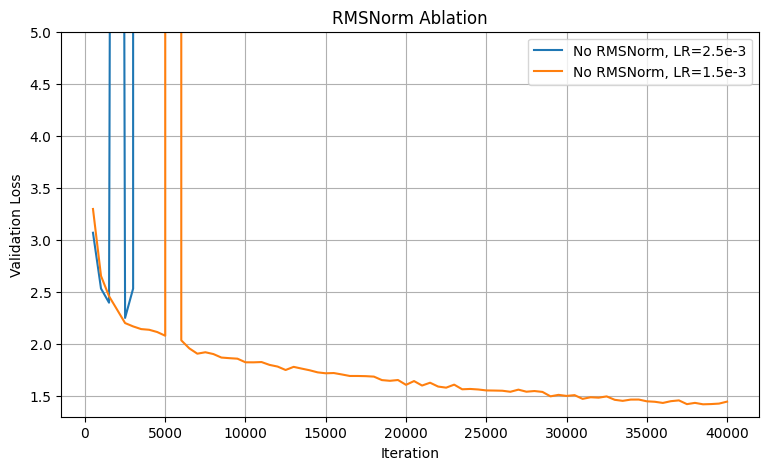

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

bad = pd.read_csv("data/no_rmsnorm_lr2p5e-3_metrics.csv")
good = pd.read_csv("data/no_rmsnorm_lr1p5e-3_metrics.csv")

# 清掉列名可能存在的空格/BOM
bad.columns = bad.columns.str.strip().str.replace("\ufeff", "", regex=False)
good.columns = good.columns.str.strip().str.replace("\ufeff", "", regex=False)

print("bad columns:", bad.columns.tolist())
print("good columns:", good.columns.tolist())

plt.figure(figsize=(9, 5))

plt.plot(
    bad.iloc[:, 0],
    bad["val_loss"],
    label="No RMSNorm, LR=2.5e-3"
)

plt.plot(
    good.iloc[:, 0],
    good["val_loss"],
    label="No RMSNorm, LR=1.5e-3"
)

plt.xlabel("Iteration")
plt.ylabel("Validation Loss")
plt.title("RMSNorm Ablation")
plt.ylim(1.3, 5)
plt.legend()
plt.grid(True)
plt.show()